In [1]:
ColabNotebook = 'google.colab' in str(get_ipython())

if ColabNotebook:
    # monta G-drive en entorno COLAB
    from google.colab import drive
    drive.mount('/content/drive/')

    DATOS_DIR = '/content/drive/MyDrive/Colab Notebooks/DATOS/HOJAS/'      # carpeta donde se encuentran los datasets
else:
    DATOS_DIR   = '../Datos/HOJAS/' # carpeta donde se encuentran los datasets

In [2]:
from skimage import io, color
from skimage.filters import threshold_otsu
from skimage.measure import regionprops, label
from skimage.morphology import closing, square
from skimage.segmentation import clear_border
import matplotlib.pyplot as plt
import numpy as np
import os


**ESTRUCTURA DE CARPETAS**

```
DATOS_DIR/
├── TRAIN/
│   ├── TREBOL/
│   └── HELECHO/
└── TEST/
    ├── TREBOL/
    └── HELECHO/
```

In [4]:
# Cargar y procesar una imagen
def procesar_imagen(nomImagen):
    
    img = io.imread(nomImagen)
    
    # Si la imagen tiene 4 canales (RGBA), convertirla a RGB
    if img.shape[-1] == 4:
        img = color.rgba2rgb(img)
    
    gris = color.rgb2gray(img)
        
    umbral = threshold_otsu(gris)
    imagen = gris < umbral  # fondo negro, hoja blanca
    
    # cierra pequeños huecos/cortes que pudiera tener la imagen 
    #imagen = closing(imagen, square(3))

    # remueve artefactos que pudiera tener la imagen en los bordes
    #imagen = clear_border(imagen)
    
    etiquetada = label(imagen)  # ← Etiquetar regiones
    regiones = regionprops(etiquetada)

    # datos de la primera región. Debería ser la única si el objeto fue segmentado correctamente
    region = regiones[0]
    
    # características invariantes a la rotación  la escala
    solidez = region.area / region.convex_area    # Qué tan convexa es la forma 
    
    ocupacion = region.area / region.bbox_area   # Qué tanto ocupa la caja que la contiene
    
    circularidad = 4 * np.pi * region.area / (region.perimeter ** 2)  # Cercanía a forma circular

    return solidez, ocupacion, circularidad, imagen


In [5]:
# Probar con dos imágenes
img1_path = os.path.join(DATOS_DIR, 'TRAIN/TREBOL', 'trebol01.png')
img2_path = os.path.join(DATOS_DIR, 'TRAIN/HELECHO', 'helecho01.png')

a1, a2, a3, bin1 = procesar_imagen(img1_path)
ab1, ab2, ab3, bin2 = procesar_imagen(img2_path)

print("TREBOL : solidez = %.4f   ocupacion = %.4f   circularidad = %.4f" % (a1, a2, a3))
print("HELECHO: solidez = %.4f   ocupacion = %.4f   circularidad = %.4f" % (ab1, ab2, ab3))


TREBOL : solidez = 0.8784   ocupacion = 0.6575   circularidad = 0.1817
HELECHO: solidez = 0.4246   ocupacion = 0.3176   circularidad = 0.0094


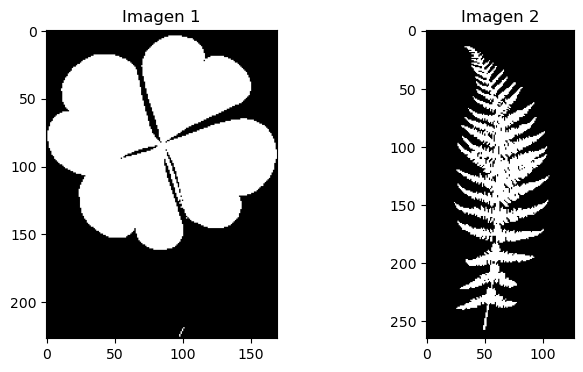

In [6]:
# Mostrar imágenes binarizadas
fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(bin1, cmap='gray')
axs[0].set_title('Imagen 1')
axs[1].imshow(bin2, cmap='gray')
axs[1].set_title('Imagen 2')
plt.show()